In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df

[===========================================================>] Completed 96,552,882 of 96,552,882 bytes (100%) /home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquett
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""loftee_categories""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
…,…,…,…,…
"""all_encode_annotations""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""all_encode_annotations""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""all_encode_annotations""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [4]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True)
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        start_stop_lost = (pl.col('consequence_start_lost') == 1) | (pl.col('consequence_stop_lost') == 1)
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_categories = ['loftee_categories', 'plof_consequences', 'missense'] # plof

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)

anno

[===========================================================>] Completed 7,370,308,270 of 7,370,308,270 bytes (100%) /home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquett


loftee_lc,region,loftee_hc,consequence_frameshift_variant,consequence_stop_lost,consequence_splice_donor_variant,id,consequence_splice_acceptor_variant,consequence_start_lost,consequence_stop_gained,consequence_missense_variant
i8,str,i8,i8,i8,i8,str,i8,i8,i8,i8
0,"""ENSG00000155657""",0,0,0,0,"""chr2:178785956:G:A""",0,0,0,0
0,"""ENSG00000155657""",0,0,0,0,"""chr2:178795028:T:C""",0,0,0,1
0,"""ENSG00000100425""",0,0,0,0,"""chr22:49798030:G:A""",0,0,0,1
0,"""ENSG00000155657""",0,0,0,0,"""chr2:178793494:G:C""",0,0,0,0
0,"""ENSG00000115020""",0,0,0,0,"""chr2:208320235:C:T""",0,0,0,0
…,…,…,…,…,…,…,…,…,…,…
0,"""ENSG00000112499""",0,0,0,0,"""chr6:160249287:G:A""",0,0,0,0
0,"""ENSG00000162852""",0,0,0,0,"""chr1:246621543:C:T""",0,0,0,1
0,"""ENSG00000258947""",0,0,0,0,"""chr16:89935768:C:T""",0,0,0,0


In [5]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )

    .filter(pl.col('annotation_score')==1)

    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    .with_columns(
        # Changed because we have binary annotations
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )

    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr1:186130026:A:G""","""ENSG00000143341""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
"""chr14:67805272:A:T""","""ENSG00000072121""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
"""chr1:11247906:C:T""","""ENSG00000198793""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
"""chr3:4316535:G:T""","""ENSG00000170364""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
"""chr10:17823281:C:T""","""ENSG00000260314""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
…,…,…,…,…,…,…
"""chr6:152220891:T:C""","""ENSG00000131018""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
"""chr4:13602215:C:G""","""ENSG00000038219""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
"""chr6:139135469:A:C""","""ENSG00000112406""","""consequence_missense_variant""",1.0,"""missense""",1,1.0


In [6]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""consequence_missense_variant""",1171029
"""loftee_hc""",125462
"""consequence_frameshift_variant""",63537
"""consequence_stop_gained""",41357
"""consequence_splice_donor_varia…",16844
"""consequence_splice_acceptor_va…",12682
"""loftee_lc""",8111
"""consequence_start_lost""",3318
"""consequence_stop_lost""",1302


In [ ]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)


Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [27]:
avg_pheno_df = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')*pl.col('loftee_corr_dir')
    )
    
    # C. Group by annotation and aggregate
    # .group_by(["annotation"])
    # .agg(
    #     n_vars = pl.col('id').n_unique(),
    #     median_pheno = pl.col('mean_pheno_value_dircor').median(),
    #     mean_pheno = pl.col('mean_pheno_value_dircor').mean(),
    #     std_pheno = pl.col('mean_pheno_value_dircor').std(),
    # )
    # .with_columns(
    #     se_pheno = pl.col('std_pheno') / pl.col('n_vars').sqrt()
    # )
    # .with_columns(
    #     ci_low_pheno = pl.col('mean_pheno') - 1.96*pl.col('se_pheno'),
    #     ci_high_pheno = pl.col('mean_pheno') + 1.96*pl.col('se_pheno'),
    # )

    .group_by(["annotation", "region", "phenotype"])
    .agg(
        n_vars = pl.col('id').n_unique(),
        mean_pheno_assoc = pl.col('mean_pheno_value_dircor').mean(),
    )
    .group_by(["annotation"])
    .agg(
        n_gene_trait_assoc = pl.col('region').n_unique(),
        mean_pheno = pl.col('mean_pheno_assoc').mean(),
        ci_low_pheno = pl.col('mean_pheno_assoc').quantile(0.025),
        ci_high_pheno = pl.col('mean_pheno_assoc').quantile(0.975),
    )

    .collect(engine='streaming')
)

avg_pheno_df

annotation,n_gene_trait_assoc,mean_pheno,ci_low_pheno,ci_high_pheno
str,u64,f64,f64,f64
"""consequence_start_lost""",369,0.217409,-1.388462,2.075795
"""loftee_lc""",272,0.12303,-1.17168,1.592639
"""loftee_hc""",670,0.644015,0.087473,1.909485
"""consequence_missense_variant""",670,0.079037,-0.06311,0.40422
"""consequence_stop_gained""",664,0.676766,-0.047865,2.12514
"""consequence_frameshift_variant""",668,0.599637,-0.062297,2.047081
"""consequence_stop_lost""",169,0.084713,-1.63294,1.847111
"""consequence_splice_acceptor_va…",595,0.543941,-0.659885,2.149733
"""consequence_splice_donor_varia…",617,0.584947,-0.555326,2.253781


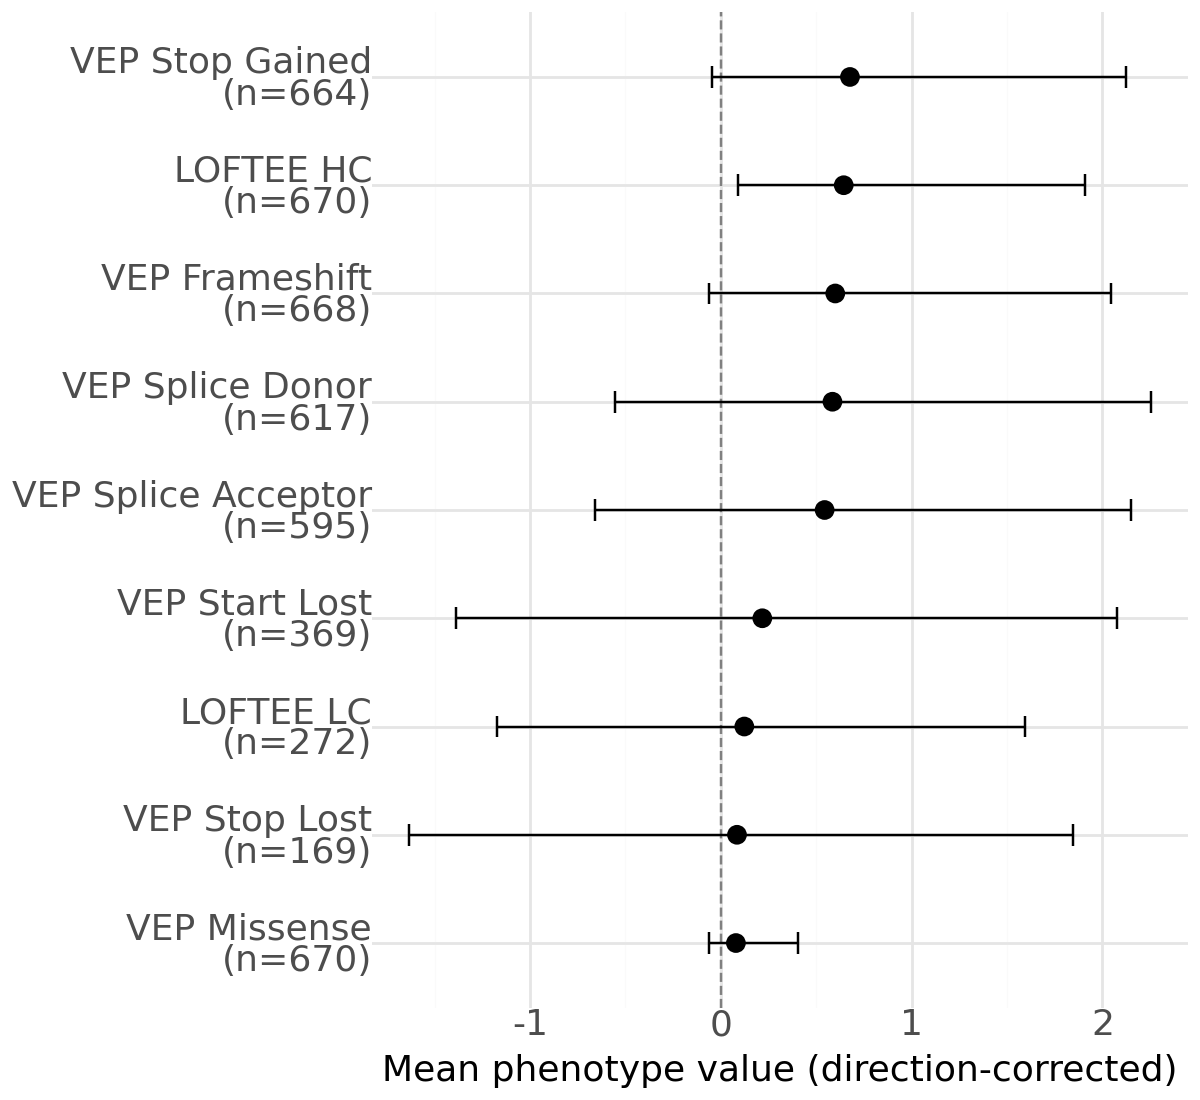

In [28]:
plotting_col = 'mean_pheno'

# Calculate medians and join back
plof_pheno_df = (
    avg_pheno_df
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .with_columns(
        # n_label = pl.col('label') + "\n(n=" + pl.col('n_vars').cast(pl.Utf8) + ")"
        n_label = pl.col('label') + "\n(n=" + pl.col('n_gene_trait_assoc').cast(pl.Utf8) + ")"
    )
    .drop_nans()
    .with_columns(
        median_mean_pheno = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    plof_pheno_df
    .sort("median_mean_pheno", descending=False)
    .select("n_label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
plof_pheno_df = plof_pheno_df.with_columns(pl.col("n_label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(plof_pheno_df.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(
        plof_pheno_df,
        aes(x='n_label', y='mean_pheno')
    )
    + geom_hline(yintercept=0, linetype='dashed', color='grey')
    + geom_point(size=3)
    + geom_errorbar(
        aes(ymin='ci_low_pheno', ymax='ci_high_pheno'),
        width=0.2,
    )
    + labs(
        x='', 
        y='Mean phenotype value (direction-corrected)'
    )
    + coord_flip()
    + theme_minimal()
    + theme(
        figure_size=(6, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)